In [1]:
import pandas as pd

# Creating a mock dataset of properties (using some sample coordinates and INR values)
data = {
    'Property_ID': [1, 2, 3, 4, 5],
    'Neighborhood': ['Tech Park Area', 'Quiet Suburbs', 'Tech Park Area', 'City Center', 'Quiet Suburbs'],
    'Latitude': [12.9716, 12.9141, 12.9750, 13.0100, 12.9200], 
    'Longitude': [77.5946, 77.6309, 77.5900, 77.5500, 77.6200],
    'Purchase_Price': [15000000, 8000000, 18000000, 12000000, 7500000],
    'Monthly_Rent': [60000, 35000, 70000, 45000, 30000]
}

# Loading it into a Pandas DataFrame (the coding equivalent of an Excel sheet)
df = pd.DataFrame(data)

# .head() displays the first 5 rows of our dataset
df.head()

,Property_ID,Neighborhood,Latitude,Longitude,Purchase_Price,Monthly_Rent
0,1,Tech Park Area,12.9716,77.5946,15000000,60000
1,2,Quiet Suburbs,12.9141,77.6309,8000000,35000
2,3,Tech Park Area,12.9750,77.5900,18000000,70000
3,4,City Center,13.0100,77.5500,12000000,45000
4,5,Quiet Suburbs,12.9200,77.6200,7500000,30000


In [2]:
# 1. Calculate the annual rent by multiplying the monthly rent by 12
df['Annual_Rent'] = df['Monthly_Rent'] * 12

# 2. Calculate the ROI percentage
df['ROI_Percentage'] = (df['Annual_Rent'] / df['Purchase_Price']) * 100

# 3. Let's round the ROI to 2 decimal places to make it look clean
df['ROI_Percentage'] = df['ROI_Percentage'].round(2)

# Display the updated table
df.head()

,Property_ID,Neighborhood,Latitude,Longitude,Purchase_Price,Monthly_Rent,Annual_Rent,ROI_Percentage
0,1,Tech Park Area,12.9716,77.5946,15000000,60000,720000,4.80
1,2,Quiet Suburbs,12.9141,77.6309,8000000,35000,420000,5.25
2,3,Tech Park Area,12.9750,77.5900,18000000,70000,840000,4.67
3,4,City Center,13.0100,77.5500,12000000,45000,540000,4.50
4,5,Quiet Suburbs,12.9200,77.6200,7500000,30000,360000,4.80


In [3]:
import folium

# 1. Find the center of our map by averaging the coordinates
center_lat = df['Latitude'].mean()
center_lon = df['Longitude'].mean()

# 2. Create the base map
roi_map = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# 3. Create a simple rule for color-coding the ROI
def get_color(roi):
    if roi >= 5.0:
        return 'green'
    elif roi >= 4.7:
        return 'orange'
    else:
        return 'red'

# 4. Loop through our table and drop a marker for each property
for index, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=12,
        # The popup shows the neighborhood and ROI when you click it
        popup=f"{row['Neighborhood']} - ROI: {row['ROI_Percentage']}%",
        color=get_color(row['ROI_Percentage']),
        fill=True,
        fill_color=get_color(row['ROI_Percentage']),
        fill_opacity=0.7
    ).add_to(roi_map)

# 5. Display the map right here in the notebook
roi_map

In [5]:
import pandas as pd

# Replace 'your_downloaded_file.csv' with the exact name of the file you uploaded
real_df = pd.read_csv('banglore3final.csv')

# Let's see what the real data looks like!
real_df.head()

,actualprice,amenities,auto_des,bedrooms,booking_amt,city,covAreaUnit,flooring_typ,fur_unfur,house_facing,...,no_balconies,parking,possesionby,power_status,property_typ,psnstats,seller_type,sqftprice,tenantsPreference,water_status
0,28764288,"Town House,Large Clubhouse ,Air Conditioned,La...","4 BHK, Villa is available for Sale in Budigere...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,...,NaN,1 Covered,NaN,NaN,NaN,NaN,builder,NaN,bachelors,NaN
1,28240000,"Town House,Large Clubhouse ,Air Conditioned,La...","4 BHK, Villa is available for Sale in Devanaha...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,...,NaN,1 Covered,NaN,NaN,NaN,NaN,owner,NaN,couples,NaN
2,12500000,"Town House,Large Clubhouse ,Air Conditioned,La...","3 BHK, Villa is available for Sale in Kanakapu...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,...,NaN,1 Open,NaN,NaN,NaN,NaN,owner,NaN,bachelors,NaN
3,27295824,"Town House,Large Clubhouse ,Air Conditioned,La...","4 BHK, Villa is available for Sale in Sarjapur...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,...,NaN,1 Covered,NaN,NaN,NaN,NaN,owner,NaN,family,NaN
4,17351475,"Town House,Large Clubhouse ,Air Conditioned,La...","4 BHK, Villa is available for Sale in Whitefie...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,...,NaN,1 Covered,NaN,NaN,NaN,NaN,contracter,NaN,onlygirls,NaN


In [6]:
# This prints out every column name and the exact number of missing (null) values it has
print(real_df.isnull().sum())

actualprice             0
amenities            1283
auto_des                0
bedrooms             5998
booking_amt          6048
city                    0
covAreaUnit          4841
flooring_typ         5842
fur_unfur            5998
house_facing         5992
landmarks               0
lat                  5113
locality             4879
lon                  5113
main_charges            0
no_balconies         5992
parking               759
possesionby          5842
power_status         5998
property_typ         4879
psnstats             4841
seller_type             0
sqftprice            6051
tenantsPreference       0
water_status         6005
dtype: int64


In [8]:
# Defining the absolute essential columns for our spatial and aesthetic analysis
essential_columns = ['actualprice', 'lat', 'lon', 'bedrooms', 'fur_unfur', 'property_typ']

# Drop any row that is missing data in these specific columns
clean_df = real_df.dropna(subset=essential_columns)

# Let's see how many rows survived the purge
print(f"Total properties left for analysis: {len(clean_df)}")

# Let's also check the data types to see if 'actualprice' is ready for math
print(clean_df[['actualprice', 'bedrooms', 'lat', 'lon']].dtypes)

Total properties left for analysis: 4310
actualprice      int64
bedrooms       float64
lat            float64
lon            float64
dtype: object


In [9]:
import folium

# 1. Engineer our spatial valuation metric (preventing division by zero just in case)
clean_df = clean_df[clean_df['bedrooms'] > 0].copy()
clean_df['Price_Per_Bedroom'] = clean_df['actualprice'] / clean_df['bedrooms']

# 2. Find the geographic center of our data
center_lat = clean_df['lat'].mean()
center_lon = clean_df['lon'].mean()

# 3. Create the base map
real_estate_map = folium.Map(location=[center_lat, center_lon], zoom_start=11)

# 4. Take a random sample of 800 properties to keep the map running smoothly
sample_df = clean_df.sample(800, random_state=42)

# 5. Define a function to color-code based on the overall property price
# Adjusting the thresholds based on typical Bangalore property prices (in INR)
def get_price_color(price):
    if price >= 15000000:  # 1.5 Cr+ (Luxury/High End)
        return 'red'
    elif price >= 7500000: # 75 Lakhs - 1.5 Cr (Mid Range)
        return 'orange'
    else:                  # Under 75 Lakhs (Budget/Starter)
        return 'green'

# 6. Drop the markers onto the map
for index, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        # The popup now shows the exact spatial breakdown
        popup=(f"Price: ₹{row['actualprice']:,}<br>"
               f"Beds: {row['bedrooms']}<br>"
               f"Furnished: {row['fur_unfur']}<br>"
               f"Type: {row['property_typ']}"),
        color=get_price_color(row['actualprice']),
        fill=True,
        fill_color=get_price_color(row['actualprice']),
        fill_opacity=0.6,
        weight=1
    ).add_to(real_estate_map)

# 7. Display the map
real_estate_map

In [11]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. We create a copy of our clean dataframe to avoid messing up the original map data
ml_df = clean_df.copy()

# 2. Convert categorical text columns into numeric codes
# This changes 'Furnished', 'Semi-Furnished' into 0, 1, 2, etc.
ml_df['fur_unfur_code'] = ml_df['fur_unfur'].astype('category').cat.codes
ml_df['property_typ_code'] = ml_df['property_typ'].astype('category').cat.codes

# Let's verify the new numeric columns are there
ml_df[['fur_unfur', 'fur_unfur_code', 'property_typ', 'property_typ_code']].head()

,fur_unfur,fur_unfur_code,property_typ,property_typ_code
14,Unfurnished,2,Villa,1
15,Unfurnished,2,Villa,1
16,Unfurnished,2,Villa,1
17,Unfurnished,2,Villa,1
18,Unfurnished,2,Villa,1


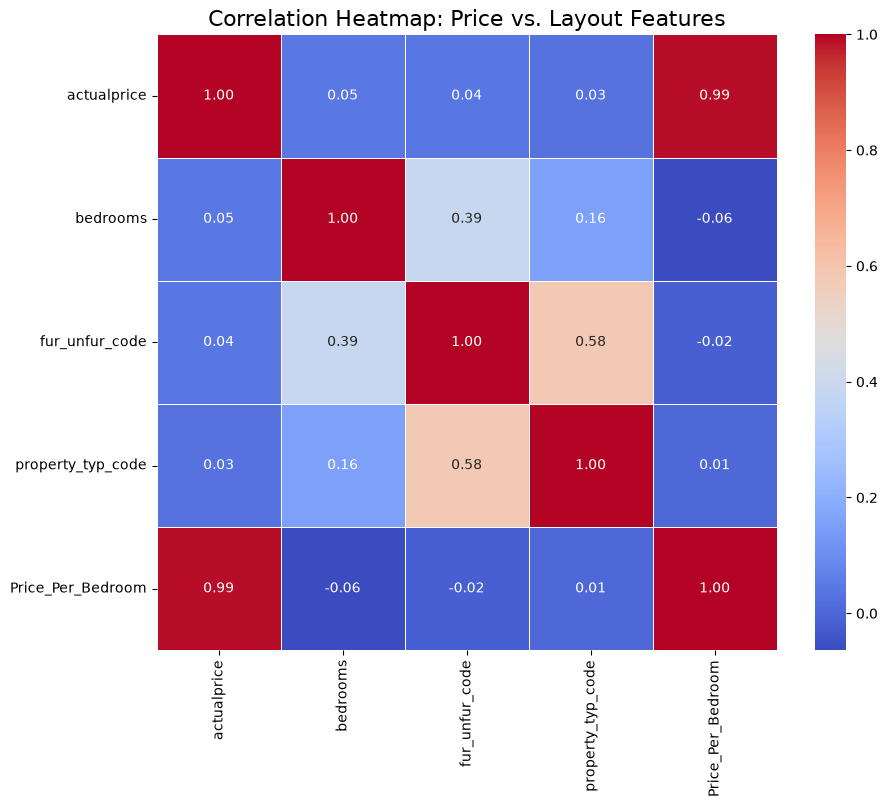

In [14]:
# 1. Define the specific columns we want to analyze
features_to_analyze = ['actualprice', 'bedrooms', 'fur_unfur_code', 'property_typ_code', 'Price_Per_Bedroom']

# 2. Calculate the correlation matrix using the built-in pandas method
correlation_matrix = ml_df[features_to_analyze].corr()

# 3. Use Matplotlib and Seaborn to visualize the matrix as a heatmap
plt.figure(figsize=(10, 8))
# The 'annot=True' displays the exact correlation values inside the heatmap squares
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap: Price vs. Layout Features", fontsize=16)
plt.show()

In [16]:
# This exports your cleaned dataframe to a new file, dropping the Pandas index numbers
clean_df.to_csv('Cleaned_Bangalore_Housing.csv', index=False)

In [17]:
import os
print(os.getcwd())

C:\Users\karth
